# Logistic Regression

**Logistic regression** is the appropriate regression analysis to conduct when the dependent variable is dichotomous (binary). Like all regression analyses, the logistic regression is a predictive analysis. Logistic regression is used to describe data and to explain the relationship between one dependent binary variable and one or more nominal, ordinal, interval or ratio-level independent variables.

Logistic Regression is used when the dependent variable (target) is categorical.

For example:

- To predict whether an email is spam (1) or (0).
- Whether online transaction is fraudulent (1) or not (0).
- Whether the tumor is malignant (1) or not (0).

**Import Dependencies**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math


# Import custom logistic regression implementation.
from logistic_regression import LogisticRegression

***Note***

`polynomial_degree` - this parameter will allow you to add additional polynomial features of certain degree. More features - more curved the line will be.

`max_iterations` - this is the maximum number of iterations that gradient descent algorithm will use to find the minimum of a cost function. Low numbers may prevent gradient descent from reaching the minimum. High numbers will make the algorithm work longer without improving its accuracy.

`regularization_param` - parameter that will fight overfitting. The higher the parameter, the simplier is the model will be.

`polynomial_degree` - the degree of additional polynomial features (`x1^2 * x2, x1^2 * x2^2, ...`). This will allow you to curve the predictions.

`sinusoid_degree` - the degree of sinusoid parameter multipliers of additional features (`sin(x), sin(2*x), ...`). This will allow you to curve the predictions by adding sinusoidal component to the prediction curve.

## 1. Logistic Regression With Linear Boundary

> **Demo Project**: In this example we will try to classify Iris flowers into tree categories (`Iris setosa`, `Iris virginica` and `Iris versicolor`) based on `petal_length` and `petal_width` parameters.

In [2]:
# Load the Data and print first rows
data = pd.read_csv('iris.csv')
data.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,SETOSA
1,4.9,3.0,1.4,0.2,SETOSA
2,4.7,3.2,1.3,0.2,SETOSA
3,4.6,3.1,1.5,0.2,SETOSA
4,5.0,3.6,1.4,0.2,SETOSA


**Plot the Data**

Let's take two parameters `petal_length` and `petal_width` for each flower into consideration and plot the dependency of the Iris class on these two parameters.

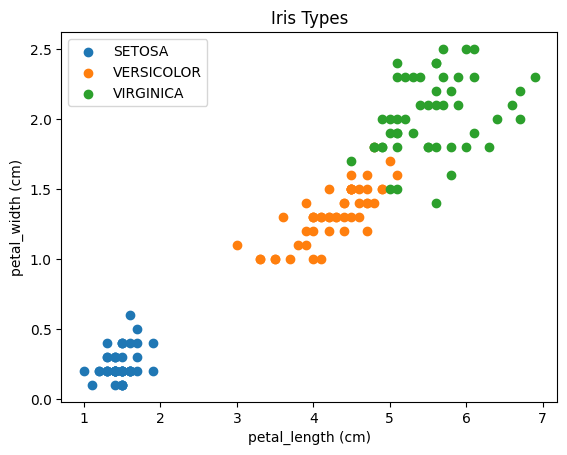

In [3]:
# List of suppported Iris classes.
iris_types = ['SETOSA', 'VERSICOLOR', 'VIRGINICA']

# Pick the Iris parameters for consideration.
x_axis = 'petal_length'
y_axis = 'petal_width'

# Plot the scatter for every type of Iris.
for iris_type in iris_types:
    plt.scatter(
        data[x_axis][data['class'] == iris_type],
        data[y_axis][data['class'] == iris_type],
        label=iris_type
    )

# Plot the data.
plt.xlabel(x_axis + ' (cm)')
plt.ylabel(y_axis + ' (cm)')
plt.title('Iris Types')
plt.legend()
plt.show()

**Prepara the Data for Training**

Let's extract `petal_length` and `petal_width` data and form a training feature set and let's also form out training labels set.

In [4]:
# Get total number of Iris examples.
num_examples = data.shape[0]

# Get features.
x_train = data[[x_axis, y_axis]].values.reshape((num_examples, 2))
# Get labels.
y_train = data['class'].values.reshape((num_examples, 1))

**Initialize and Train Logistic Regression Model**

In [5]:
# Set up linear regression parameters.
max_iterations = 1000  # Max number of gradient descent iterations.
regularization_param = 0  # Helps to fight model overfitting.
polynomial_degree = 0  # The degree of additional polynomial features.
sinusoid_degree = 0  # The degree of sinusoid parameter multipliers of additional features.

# Init logistic regression instance.
logistic_regression = LogisticRegression(x_train, y_train, polynomial_degree, sinusoid_degree)

# Train logistic regression.
(thetas, costs) = logistic_regression.train(regularization_param, max_iterations)

# Print model parameters that have been learned.
pd.DataFrame(thetas, columns=['Theta 1', 'Theta 2', 'Theta 3'], index=['SETOSA', 'VERSICOLOR', 'VIRGINICA'])

,Theta 1,Theta 2,Theta 3
SETOSA,30.291853,-8.404206,-12.313125
VERSICOLOR,-2.858904,1.546523,-3.107221
VIRGINICA,-45.349540,5.766294,10.458614


**Analyze Gradient Descent Progress**

The plot below illustrates how the cost function value changes over each iteration. You should see it decreasing.

In case if cost function value increases it may mean that gradient descent missed the cost function minimum and with each step it goes further away from it.

From this plot you may also get an understanding of how many iterations you need to get an optimal value of the cost function.

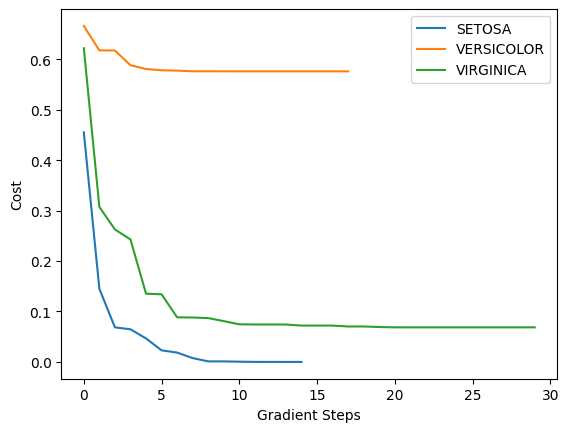

In [6]:
# Draw gradient descent progress for each label.
labels = logistic_regression.unique_labels
plt.plot(range(len(costs[0])), costs[0], label=labels[0])
plt.plot(range(len(costs[1])), costs[1], label=labels[1])
plt.plot(range(len(costs[2])), costs[2], label=labels[2])

plt.xlabel('Gradient Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()

**Calculate Model Training Precision**

Calculate how many flowers from the training set have been guessed correctly.

In [7]:
# Make training set predictions.
y_train_predictions = logistic_regression.predict(x_train)

# Check what percentage of them are actually correct.
precision = np.sum(y_train_predictions == y_train) / y_train.shape[0] * 100

print('Precision: {:5.4f}%'.format(precision))

Precision: 96.0000%


**Draw Decision Boundaries**

Let's build our decision boundaries. These are the lines that distinguish classes from each other. This will give us a pretty clear overview of how successfull our training process was. You should see clear distinguishment of three sectors on the data plain.

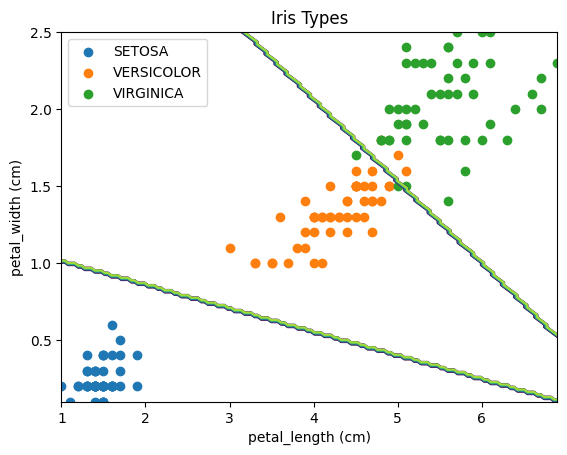

In [8]:
# Get the number of training examples.
num_examples = x_train.shape[0]

# Set up how many calculations we want to do along every axis.
samples = 150

# Generate test ranges for x and y axis.
x_min = np.min(x_train[:, 0])
x_max = np.max(x_train[:, 0])

y_min = np.min(x_train[:, 1])
y_max = np.max(x_train[:, 1])

X = np.linspace(x_min, x_max, samples)
Y = np.linspace(y_min, y_max, samples)

# z axis will contain our predictions. So let's get predictions for every pair of x and y.
Z_setosa = np.zeros((samples, samples))
Z_versicolor = np.zeros((samples, samples))
Z_virginica = np.zeros((samples, samples))

for x_index, x in enumerate(X):
    for y_index, y in enumerate(Y):
        data = np.array([[x, y]])
        prediction = logistic_regression.predict(data)[0][0]
        if prediction == 'SETOSA':
            Z_setosa[x_index][y_index] = 1
        elif prediction == 'VERSICOLOR':
            Z_versicolor[x_index][y_index] = 1
        elif prediction == 'VIRGINICA':
            Z_virginica[x_index][y_index] = 1

# Now, when we have x, y and z axes being setup and calculated we may print decision boundaries.
for iris_type in iris_types:
    plt.scatter(
        x_train[(y_train == iris_type).flatten(), 0],
        x_train[(y_train == iris_type).flatten(), 1],
        label=iris_type
    )

plt.contour(X, Y, Z_setosa)
plt.contour(X, Y, Z_versicolor)
plt.contour(X, Y, Z_virginica)

plt.xlabel(x_axis + ' (cm)')
plt.ylabel(y_axis + ' (cm)')
plt.title('Iris Types')
plt.legend()
plt.show()

## Logistic Regression With Non-Linear Boundary

In [10]:
# Load the data and print first rows
data = pd.read_csv('microchips-tests.csv')
data.head()

,param_1,param_2,validity
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


**Plot the Data**

Let's plot the data on 2D-plane and split it by two clasess (`valid` and `invalid`) to see the distribution.

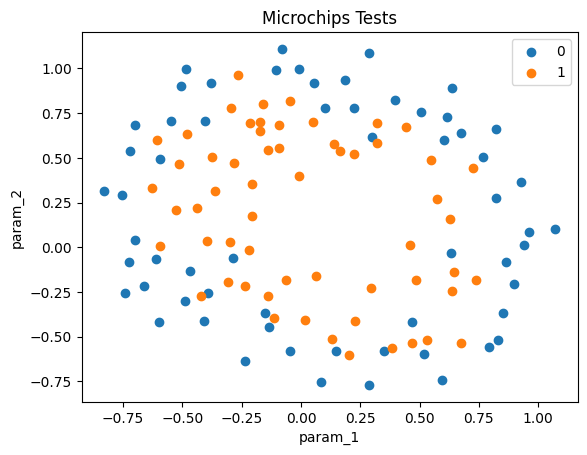

In [11]:
# Supported set of validities.
validities = [0, 1]

# Dataset parameters that we will take into account.
x_axis = 'param_1'
y_axis = 'param_2'

# Scatter the data on the plot for each validity class separatelly.
for validity in validities:
    plt.scatter(
        data[x_axis][data['validity'] == validity],
        data[y_axis][data['validity'] == validity],
        label=validity
    )

# Plot the data.
plt.xlabel(x_axis)
plt.ylabel(y_axis)
plt.title('Microchips Tests')
plt.legend()
plt.show()

**Prepare the Data for Training**

Before we move on with training our logistic model let's extract the data from Pandas data frame and shape training features set and labels set correctly.

In [12]:
# Get the number of training examples.
num_examples = data.shape[0]

# Extract and shape features.
x_train = data[[x_axis, y_axis]].values.reshape((num_examples, 2))

# Extract and shape labels.
y_train = data['validity'].values.reshape((num_examples, 1))

**Initialize and Train Logistic Regression Model**

In [13]:
# Set up linear regression parameters.
max_iterations = 100000  # Max number of gradient descent iterations.
regularization_param = 0  # Helps to fight model overfitting.
polynomial_degree = 5  # The degree of additional polynomial features.
sinusoid_degree = 0  # The degree of sinusoid parameter multipliers of additional features.

# Init logistic regression instance.
logistic_regression = LogisticRegression(x_train, y_train, polynomial_degree, sinusoid_degree)

# Train logistic regression.
(thetas, costs) = logistic_regression.train(regularization_param, max_iterations)

# Rename the columns for each theta.
columns = []
for theta_index in range(0, thetas.shape[1]):
    columns.append('Theta ' + str(theta_index));

pd.DataFrame(thetas, index=['VALID', 'INVALID'], columns=columns)

,Theta 0,Theta 1,Theta 2,Theta 3,Theta 4,Theta 5,Theta 6,Theta 7,Theta 8,Theta 9,...,Theta 13,Theta 14,Theta 15,Theta 16,Theta 17,Theta 18,Theta 19,Theta 20,Theta 21,Theta 22
VALID,-2.072964,1.460594,-1.262352,1.460594,-1.262352,-3.466208,10.938067,-10.21359,-17.894768,-25.656038,...,2.170490,39.371381,2.653250,40.290896,14.606674,18.485662,-7.842021,26.813808,43.592778,-22.901729
INVALID,2.048812,-1.519609,1.187674,-1.519609,1.187674,3.566852,-10.914037,10.23987,18.376389,26.582988,...,-2.212479,-39.729300,-3.029351,-40.365175,-15.031601,-19.355369,6.866128,-27.938948,-43.982398,22.599000


**Analyze Gradient Descent Progress**

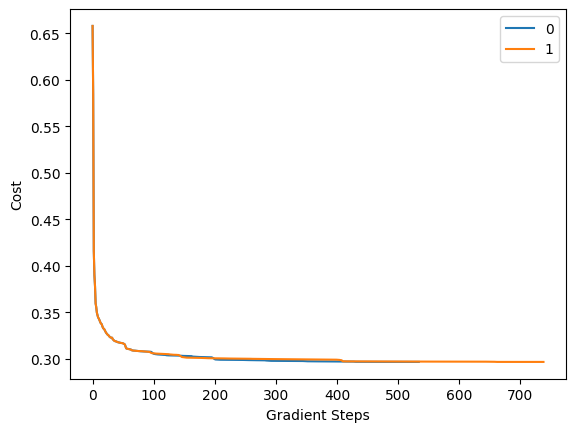

In [14]:
# Draw gradient descent progress for each label.
labels = logistic_regression.unique_labels

plt.plot(range(len(costs[0])), costs[0], label=labels[0])
plt.plot(range(len(costs[1])), costs[1], label=labels[1])

plt.xlabel('Gradient Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()

**Calculate Model Training Precision**

Calculate how many flowers from the training set have been guessed correctly.

In [15]:
# Make training set predictions.
y_train_predictions = logistic_regression.predict(x_train)

# Check what percentage of them are actually correct.
precision = np.sum(y_train_predictions == y_train) / y_train.shape[0] * 100

print('Training Precision: {:5.4f}%'.format(precision))

Training Precision: 88.9831%


**Draw Decision Boundaries**

Let's build our decision boundaries. These are the lines that distinguish classes from each other. This will give us a pretty clear overview of how successfull our training process was. You should see clear distinguishment of three sectors on the data plain.

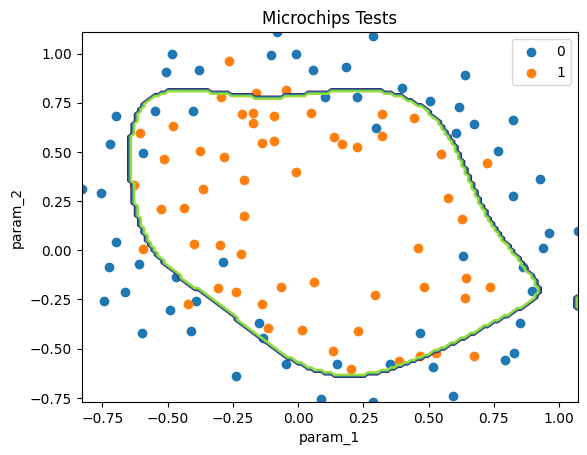

In [16]:
# Get the number of training examples.
num_examples = x_train.shape[0]

# Set up how many calculations we want to do along every axis.
samples = 150

# Generate test ranges for x and y axis.
x_min = np.min(x_train[:, 0])
x_max = np.max(x_train[:, 0])

y_min = np.min(x_train[:, 1])
y_max = np.max(x_train[:, 1])

X = np.linspace(x_min, x_max, samples)
Y = np.linspace(y_min, y_max, samples)
Z = np.zeros((samples, samples))

# z axis will contain our predictions. So let's get predictions for every pair of x and y.
for x_index, x in enumerate(X):
    for y_index, y in enumerate(Y):
        data = np.array([[x, y]])
        Z[x_index][y_index] = logistic_regression.predict(data)[0][0]

# Now, when we have x, y and z axes being setup and calculated we may print decision boundaries.
positives = (y_train == 1).flatten()
negatives = (y_train == 0).flatten()

plt.scatter(x_train[negatives, 0], x_train[negatives, 1], label='0')
plt.scatter(x_train[positives, 0], x_train[positives, 1], label='1')

plt.contour(X, Y, Z)

plt.xlabel('param_1')
plt.ylabel('param_2')
plt.title('Microchips Tests')
plt.legend()

plt.show()

## Multivariate Logistic Regression

In [18]:
# Load the data and print the first rows
data = pd.read_csv('mnist-demo.csv')
data.head(10)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Plot the Data**

Let's peek first 25 rows of the dataset and display them as an images to have an example of digits we will be working with.

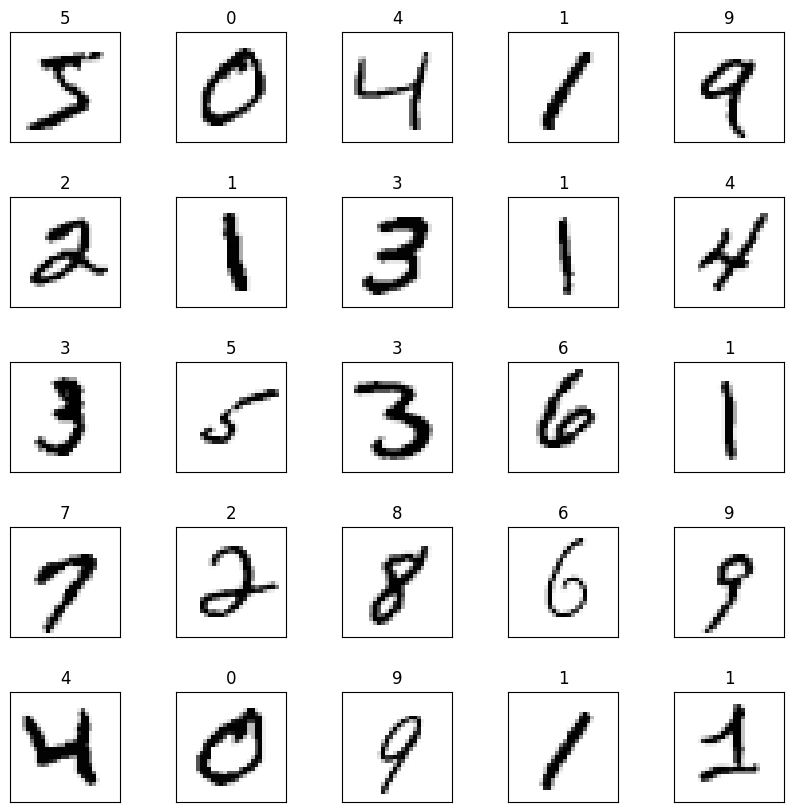

In [19]:
# How many numbers to display.
numbers_to_display = 25

# Calculate the number of cells that will hold all the numbers.
num_cells = math.ceil(math.sqrt(numbers_to_display))

# Make the plot a little bit bigger than default one.
plt.figure(figsize=(10, 10))

# Go through the first numbers in a training set and plot them.
for plot_index in range(numbers_to_display):
    # Extrace digit data.
    digit = data[plot_index:plot_index + 1].values
    digit_label = digit[0][0]
    digit_pixels = digit[0][1:]

    # Calculate image size (remember that each picture has square proportions).
    image_size = int(math.sqrt(digit_pixels.shape[0]))

    # Convert image vector into the matrix of pixels.
    frame = digit_pixels.reshape((image_size, image_size))

    # Plot the number matrix.
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(frame, cmap='Greys')
    plt.title(digit_label)
    plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Plot all subplots.
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

**Split the Data Into Training and Test Sets**

In this step we will split our dataset into training and testing subsets (in proportion 80/20%).

Training data set will be used for training of our model. Testing dataset will be used for validating of the model. All data from testing dataset will be new to model and we may check how accurate are model predictions.

In [20]:
# Function sample() returns a random sample of items.
pd_train_data = data.sample(frac=0.8)
pd_test_data = data.drop(pd_train_data.index)

# Convert training and testing data from Pandas to NumPy format.
train_data = pd_train_data.values
test_data = pd_test_data.values

# Extract training/test labels and features.
num_training_examples = 6000
x_train = train_data[:num_training_examples, 1:]
y_train = train_data[:num_training_examples, [0]]

x_test = test_data[:, 1:]
y_test = test_data[:, [0]]

**Initialize and Train Logistic Regression Model**

In [21]:
# Set up linear regression parameters.
max_iterations = 10000  # Max number of gradient descent iterations.
regularization_param = 10  # Helps to fight model overfitting.
polynomial_degree = 0  # The degree of additional polynomial features.
sinusoid_degree = 0  # The degree of sinusoid parameter multipliers of additional features.
normalize_data = True  # Whether we need to normalize data to make it more unifrom or not.

# Init logistic regression instance.
logistic_regression = LogisticRegression(x_train, y_train, polynomial_degree, sinusoid_degree, normalize_data)

# Train logistic regression.
(thetas, costs) = logistic_regression.train(regularization_param, max_iterations)

**Print Training Results**

Let's see how model parameters (thetas) look like. For each digit class (from 0 to 9) we've just trained a set of 784 parameters (one theta for each image pixel). These parameters represents the importance of every pixel for specific digit recognition.

In [22]:
pd.DataFrame(thetas)

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,-9.756202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.013996,-0.005921,-0.000408,-0.000127,0.000137,0.0,0.0,0.0,0.0,0.0
1,-12.302063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.011663,-0.003851,0.000088,0.000144,0.000117,0.0,0.0,0.0,0.0,0.0
2,-7.738119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000127,0.000011,0.000211,-0.044183,-0.081979,0.0,0.0,0.0,0.0,0.0
3,-7.556267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.012789,-0.007125,0.000098,0.000115,-0.000068,0.0,0.0,0.0,0.0,0.0
4,-9.857912,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.049285,0.000191,0.000085,0.000141,0.000080,0.0,0.0,0.0,0.0,0.0
5,-7.510847,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.025746,-0.003016,0.000457,-0.000810,-0.002052,0.0,0.0,0.0,0.0,0.0
6,-9.488878,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.004913,0.000166,0.000119,0.000103,0.000064,0.0,0.0,0.0,0.0,0.0
7,-10.643921,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.076370,0.006171,-0.022076,-0.001757,-0.078012,0.0,0.0,0.0,0.0,0.0
8,-6.255932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.007434,-0.005004,0.000464,0.000299,-0.000164,0.0,0.0,0.0,0.0,0.0
9,-8.546964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.023713,-0.032631,0.022615,0.020856,0.089462,0.0,0.0,0.0,0.0,0.0


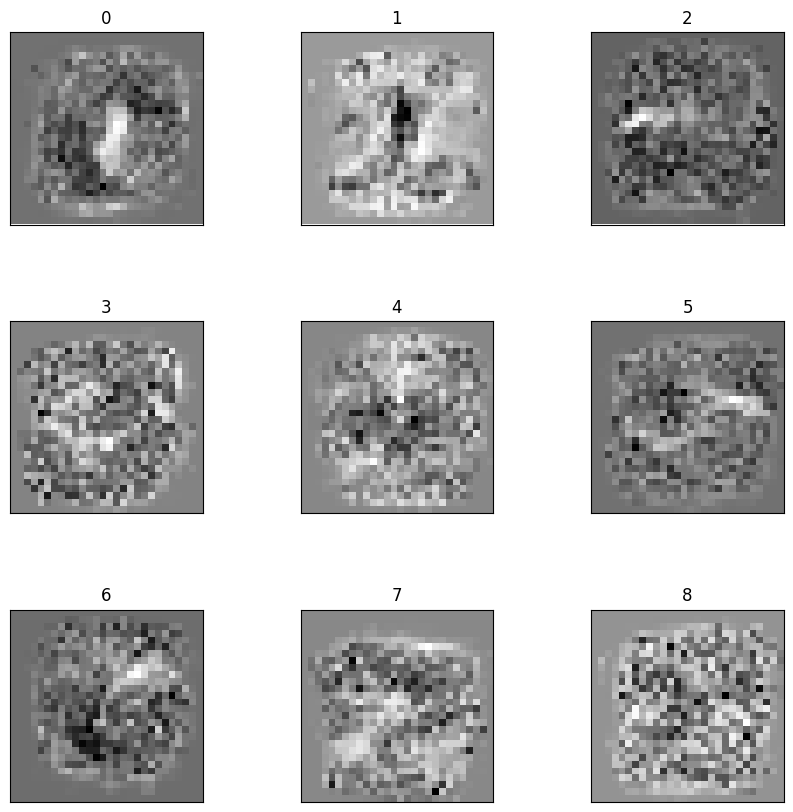

In [23]:
# How many numbers to display.
numbers_to_display = 9

# Calculate the number of cells that will hold all the numbers.
num_cells = math.ceil(math.sqrt(numbers_to_display))

# Make the plot a little bit bigger than default one.
plt.figure(figsize=(10, 10))

# Go through the thetas and print them.
for plot_index in range(numbers_to_display):
    # Extrace digit data.
    digit_pixels = thetas[plot_index][1:]

    # Calculate image size (remember that each picture has square proportions).
    image_size = int(math.sqrt(digit_pixels.shape[0]))

    # Convert image vector into the matrix of pixels.
    frame = digit_pixels.reshape((image_size, image_size))

    # Plot the number matrix.
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(frame, cmap='Greys')
    plt.title(plot_index)
    plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Plot all subplots.
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

**Analyze Gradient Descent Progress**

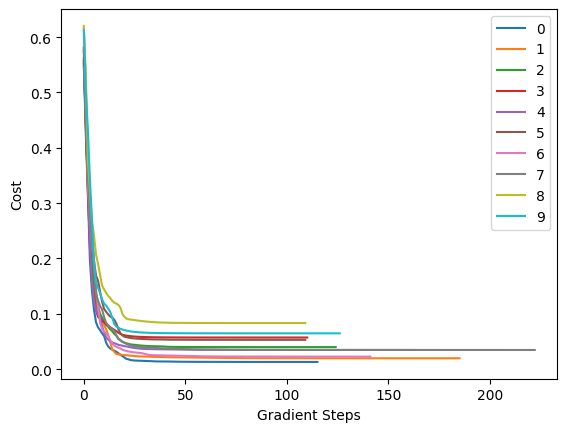

In [24]:
# Draw gradient descent progress for each label.
labels = logistic_regression.unique_labels
for index, label in enumerate(labels):
    plt.plot(range(len(costs[index])), costs[index], label=labels[index])

plt.xlabel('Gradient Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()

**Calculate Model Training Precision**

Calculate how many of training and test examples have been classified correctly. Normally we need test precission to be as high as possible. In case if training precision is high and test precission is low it may mean that our model is overfitted (it works really well with the training data set but it is not good at classifying new unknown data from the test dataset). In this case you may want to play with `regularization_param` parameter to fighth the overfitting.

In [25]:
# Make training set predictions.
y_train_predictions = logistic_regression.predict(x_train)
y_test_predictions = logistic_regression.predict(x_test)

# Check what percentage of them are actually correct.
train_precision = np.sum(y_train_predictions == y_train) / y_train.shape[0] * 100
test_precision = np.sum(y_test_predictions == y_test) / y_test.shape[0] * 100

print('Training Precision: {:5.4f}%'.format(train_precision))
print('Test Precision: {:5.4f}%'.format(test_precision))

Training Precision: 96.9167%
Test Precision: 90.0000%


**Plot Test Dataset Predictions**

In order to illustrate how our model classifies unknown examples let's plot first 64 predictions for testing dataset. All green digits on the plot below have been recognized corrctly but all the red digits have not been recognized correctly by our classifier. On top of each digit image you may see the class (the number) that has been recognized on the image.

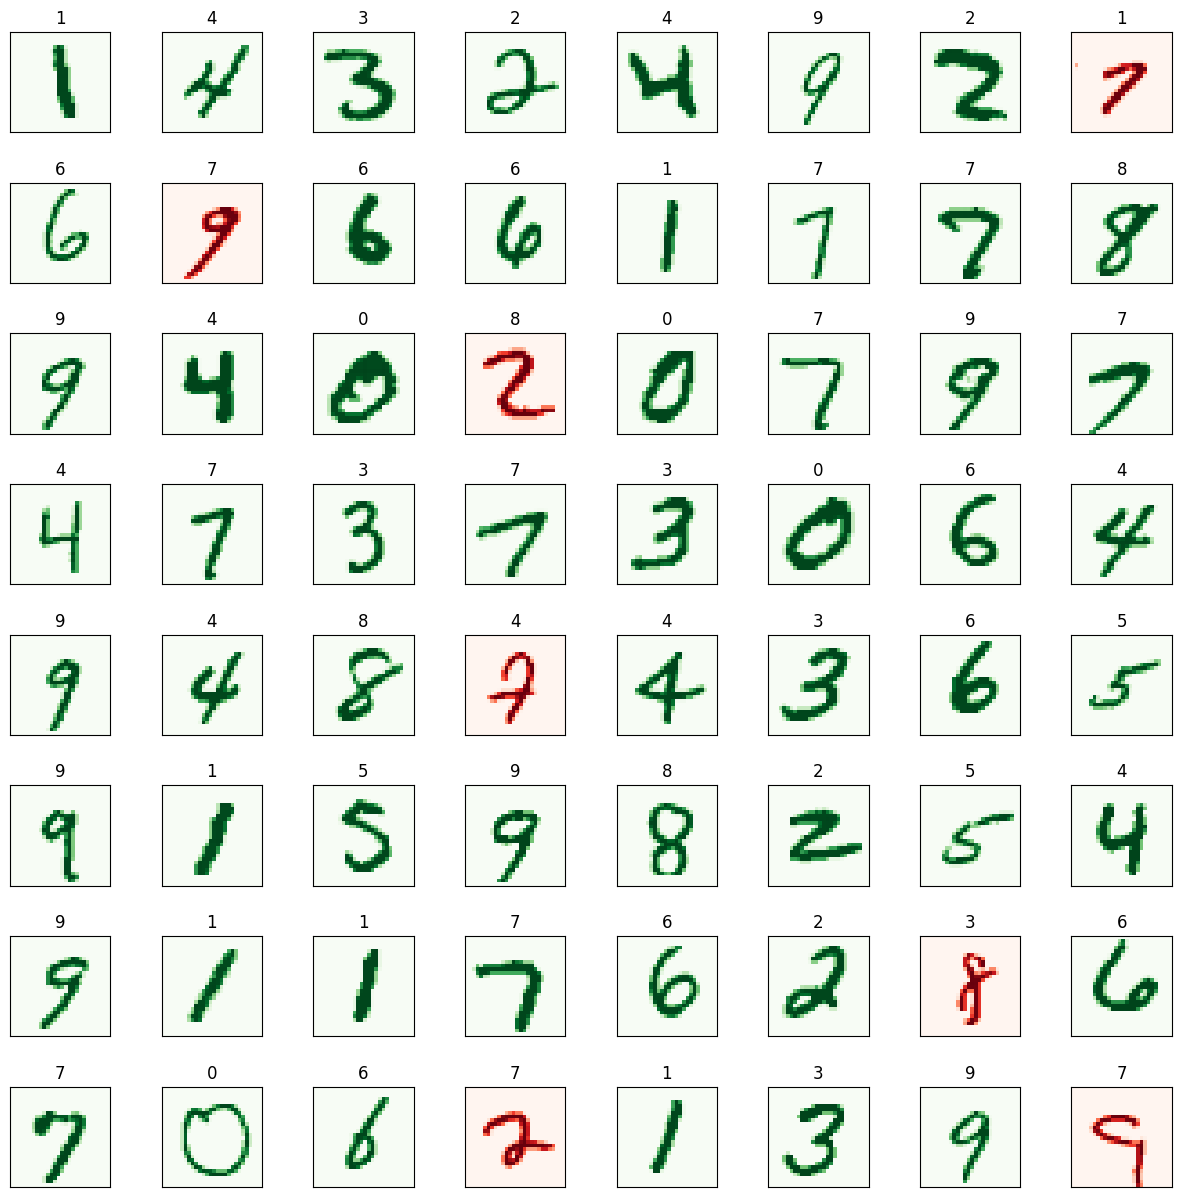

In [26]:
# How many numbers to display.
numbers_to_display = 64

# Calculate the number of cells that will hold all the numbers.
num_cells = math.ceil(math.sqrt(numbers_to_display))

# Make the plot a little bit bigger than default one.
plt.figure(figsize=(15, 15))

# Go through the first numbers in a test set and plot them.
for plot_index in range(numbers_to_display):
    # Extrace digit data.
    digit_label = y_test[plot_index, 0]
    digit_pixels = x_test[plot_index, :]

    # Predicted label.
    predicted_label = y_test_predictions[plot_index][0]

    # Calculate image size (remember that each picture has square proportions).
    image_size = int(math.sqrt(digit_pixels.shape[0]))

    # Convert image vector into the matrix of pixels.
    frame = digit_pixels.reshape((image_size, image_size))

    # Plot the number matrix.
    color_map = 'Greens' if predicted_label == digit_label else 'Reds'
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(frame, cmap=color_map)
    plt.title(predicted_label)
    plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Plot all subplots.
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()


**Load the Data**

In this demo we will use a sample of Fashion MNIST dataset in a CSV format.

Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Zalando intends Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.

Instead of using full dataset with 60000 training examples we will use cut dataset of just 5000 examples that we will also split into training and testing sets.

Each row in the dataset consists of 785 values: the first value is the label (a category from 0 to 9) and the remaining 784 values (28x28 pixels image) are the pixel values (a number from 0 to 255).

Each training and test example is assigned to one of the following labels:

- 0 T-shirt/top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandal
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boot

In [27]:
data = pd.read_csv('fashion-mnist-demo.csv')

# Lets create the mapping between numeric category and category name.
label_map = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot',
}

data.head(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


**Plot the Data**

Let's peek first 25 rows of the dataset and display them as an images to have an example of clothes we will be working with.

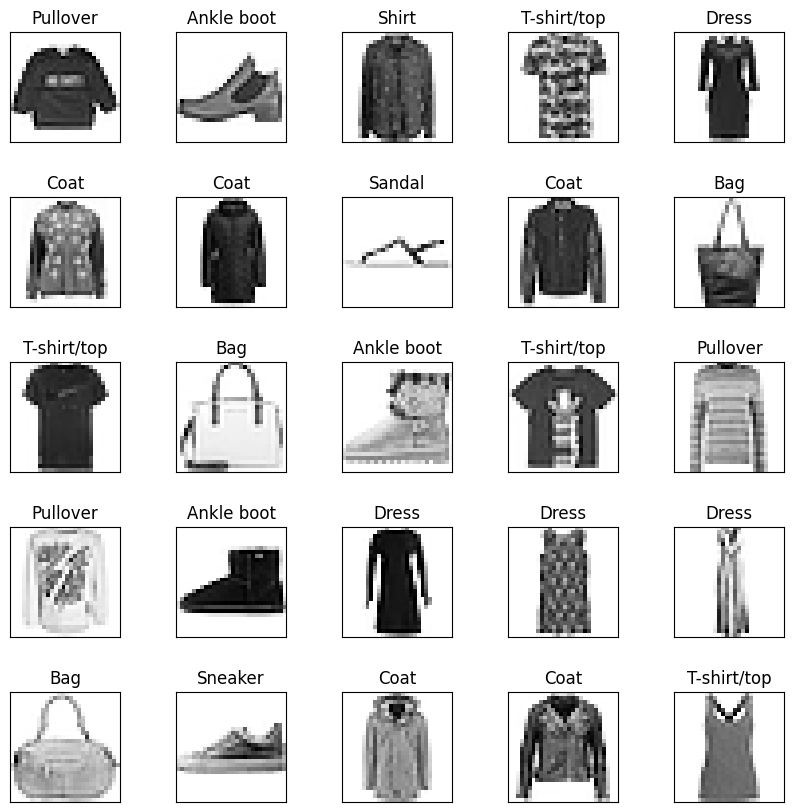

In [28]:
# How many images to display.
numbers_to_display = 25

# Calculate the number of cells that will hold all the images.
num_cells = math.ceil(math.sqrt(numbers_to_display))

# Make the plot a little bit bigger than default one.
plt.figure(figsize=(10, 10))

# Go through the first images in a training set and plot them.
for plot_index in range(numbers_to_display):
    # Extrace image data.
    digit = data[plot_index:plot_index + 1].values
    digit_label = digit[0][0]
    digit_pixels = digit[0][1:]

    # Calculate image size (remember that each picture has square proportions).
    image_size = int(math.sqrt(digit_pixels.shape[0]))

    # Convert image vector into the matrix of pixels.
    frame = digit_pixels.reshape((image_size, image_size))

    # Plot the image matrix.
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(frame, cmap='Greys')
    plt.title(label_map[digit_label])
    plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Plot all subplots.
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

**Split the Data Into Training and Test Sets**

In this step we will split our dataset into training and testing subsets (in proportion 80/20%).

In [29]:
# Function sample() returns a random sample of items.
pd_train_data = data.sample(frac=0.8)
pd_test_data = data.drop(pd_train_data.index)

# Convert training and testing data from Pandas to NumPy format.
train_data = pd_train_data.values
test_data = pd_test_data.values

# Extract training/test labels and features.
num_training_examples = 3000
x_train = train_data[:num_training_examples, 1:]
y_train = train_data[:num_training_examples, [0]]

x_test = test_data[:, 1:]
y_test = test_data[:, [0]]

**Initialize and Train Logistic Regression Model**

In [30]:
# Set up linear regression parameters.
max_iterations = 10000  # Max number of gradient descent iterations.
regularization_param = 25  # Helps to fight model overfitting.
polynomial_degree = 0  # The degree of additional polynomial features.
sinusoid_degree = 0  # The degree of sinusoid parameter multipliers of additional features.
normalize_data = True  # Whether we need to normalize data to make it more unifrom or not.

# Init logistic regression instance.
logistic_regression = LogisticRegression(x_train, y_train, polynomial_degree, sinusoid_degree, normalize_data)

# Train logistic regression.
(thetas, costs) = logistic_regression.train(regularization_param, max_iterations)

**Print Training Results**

In [31]:
pd.DataFrame(thetas)

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,-6.166845,0.0,-0.039375,-0.049028,0.096481,0.182765,0.182465,-0.093144,-0.067506,0.001188,...,-0.081030,-0.100229,0.223967,0.103428,0.119179,0.008619,-0.093405,-0.074031,-0.031152,-0.012598
1,-6.360235,0.0,-0.011499,-0.010333,-0.022609,0.209148,-0.045672,0.082538,0.019740,0.121469,...,0.121515,0.059236,0.001186,-0.014335,0.009303,-0.029724,-0.040696,-0.028475,-0.019331,-0.008290
2,-5.426608,0.0,0.010370,-0.144153,-0.119768,-0.004759,-0.056426,0.015614,-0.064936,-0.051825,...,-0.079716,0.119018,0.088058,0.211793,0.029529,-0.029996,-0.031636,0.028075,0.194506,0.192085
3,-6.539108,0.0,-0.009911,0.128923,-0.003495,-0.185388,0.079411,0.093155,-0.022023,-0.100521,...,0.064456,0.143564,0.019026,-0.202294,-0.178512,-0.128903,-0.068270,-0.044471,-0.040903,-0.039403
4,-6.019342,0.0,-0.007197,0.013863,0.076689,0.021177,-0.010829,-0.044530,-0.000740,-0.041369,...,0.020020,0.167614,-0.053894,-0.103943,0.102695,0.011600,0.140402,0.001165,-0.111674,-0.012073
5,-11.215248,0.0,-0.021567,-0.038481,-0.002656,-0.013753,-0.023638,-0.023781,-0.020292,-0.065104,...,0.006247,0.014449,0.010725,-0.044070,-0.088819,-0.073094,-0.045514,-0.024444,-0.056674,-0.004492
6,-4.875304,0.0,0.075211,0.064420,-0.186762,-0.224852,-0.021353,-0.063071,0.055592,0.054499,...,-0.082647,-0.057878,-0.031589,-0.084118,-0.141533,-0.046154,0.038968,0.155790,0.059481,-0.045393
7,-9.076031,0.0,-0.000017,-0.000168,-0.000422,-0.012549,-0.005459,-0.004596,-0.005557,-0.009355,...,-0.048253,-0.039055,-0.017280,-0.011489,-0.006455,-0.004525,-0.002333,-0.010374,-0.010560,-0.000022
8,-5.812522,0.0,0.053148,-0.018411,-0.043221,-0.028361,-0.068271,0.118709,-0.000529,0.003398,...,0.058395,-0.022642,0.031266,0.003768,-0.046986,-0.036152,-0.071856,-0.027318,-0.036074,-0.007615
9,-7.314380,0.0,-0.003144,-0.002756,-0.003116,-0.017403,-0.007327,-0.008399,-0.012008,-0.014563,...,-0.027665,-0.020033,-0.022631,-0.016008,0.005612,0.041644,0.041953,0.037069,0.091035,-0.020627


**Illustrate Hidden Layers Perceptrons**

Each perceptron in the hidden layer learned something from the training process. What it learned is represented by input theta parameters for it. Each perceptron in the hidden layer has 28x28 input thetas (one for each input image pizel). Each theta represents how valuable each pixel is for this particuar perceptron. So let's try to plot how valuable each pixel of input image is for each perceptron based on its theta values.

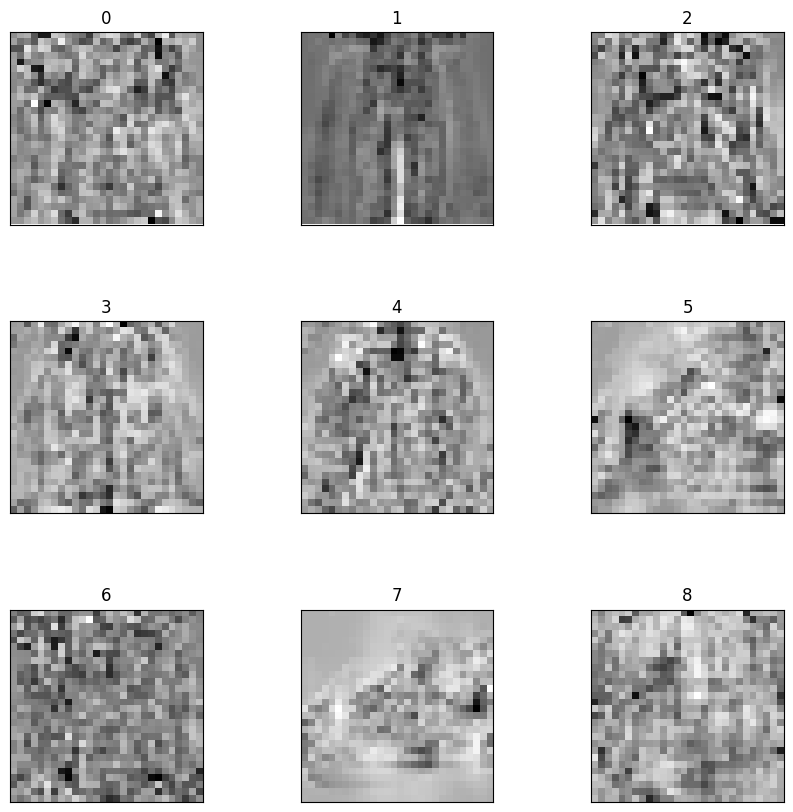

In [32]:
# How many images to display.
numbers_to_display = 9

# Calculate the number of cells that will hold all the images.
num_cells = math.ceil(math.sqrt(numbers_to_display))

# Make the plot a little bit bigger than default one.
plt.figure(figsize=(10, 10))

# Go through the thetas and print them.
for plot_index in range(numbers_to_display):
    # Extrace thetas data.
    digit_pixels = thetas[plot_index][1:]

    # Calculate image size (remember that each picture has square proportions).
    image_size = int(math.sqrt(digit_pixels.shape[0]))

    # Convert image vector into the matrix of pixels.
    frame = digit_pixels.reshape((image_size, image_size))

    # Plot the thetas matrix.
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(frame, cmap='Greys')
    plt.title(plot_index)
    plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Plot all subplots.
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

**Analyze Gradient Descent Progress**

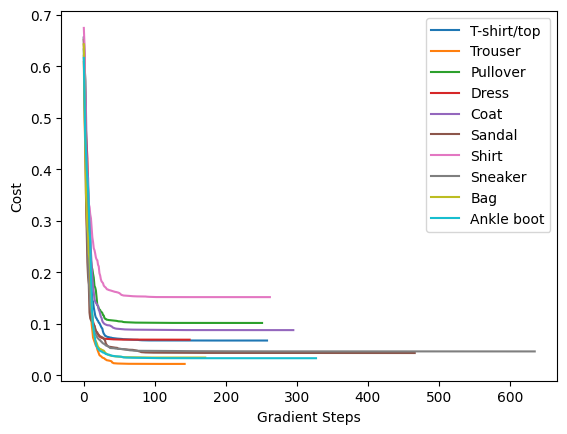

In [33]:
# Draw gradient descent progress for each label.
labels = logistic_regression.unique_labels
for index, label in enumerate(labels):
    plt.plot(range(len(costs[index])), costs[index], label=label_map[labels[index]])

plt.xlabel('Gradient Steps')
plt.ylabel('Cost')
plt.legend()
plt.show()

**Calculate Model Training Precision**

In [34]:
# Make training set predictions.
y_train_predictions = logistic_regression.predict(x_train)
y_test_predictions = logistic_regression.predict(x_test)

# Check what percentage of them are actually correct.
train_precision = np.sum(y_train_predictions == y_train) / y_train.shape[0] * 100
test_precision = np.sum(y_test_predictions == y_test) / y_test.shape[0] * 100

print('Training Precision: {:5.4f}%'.format(train_precision))
print('Test Precision: {:5.4f}%'.format(test_precision))

Training Precision: 93.5333%
Test Precision: 83.3000%


**Plot Test Dataset Predictions**

In order to illustrate how our model classifies unknown examples let's plot first 64 predictions for testing dataset. All green clothes on the plot below have been recognized corrctly but all the red clothes have not been recognized correctly by our classifier. On top of each image you may see the clothes class (type) that has been recognized on the image.

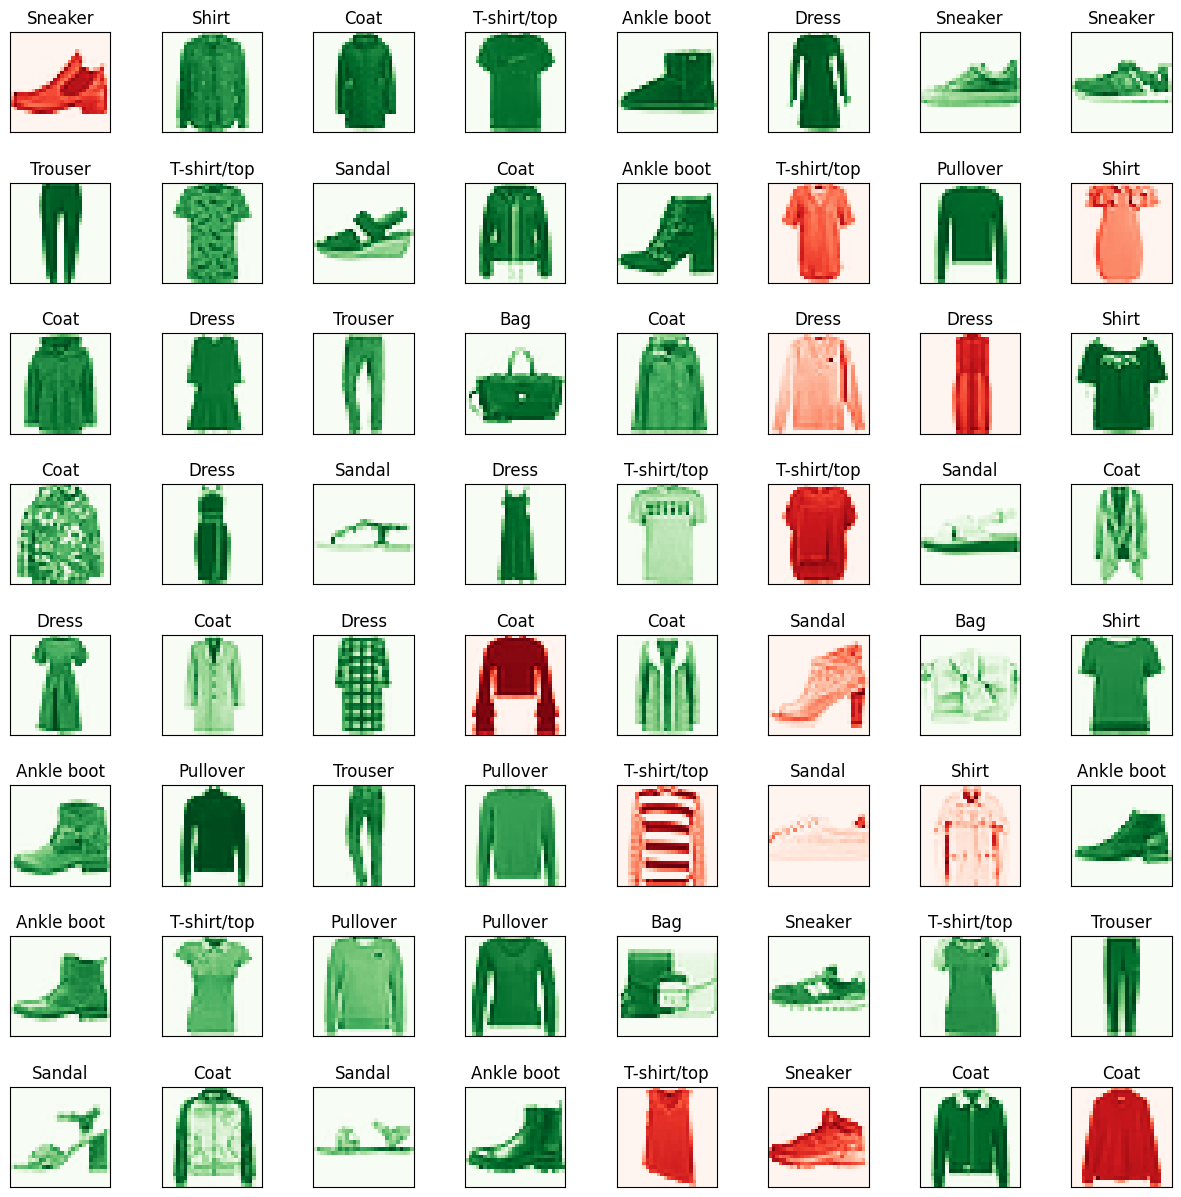

In [35]:
# How many numbers to display.
numbers_to_display = 64

# Calculate the number of cells that will hold all the numbers.
num_cells = math.ceil(math.sqrt(numbers_to_display))

# Make the plot a little bit bigger than default one.
plt.figure(figsize=(15, 15))

# Go through the first numbers in a test set and plot them.
for plot_index in range(numbers_to_display):
    # Extrace digit data.
    digit_label = y_test[plot_index, 0]
    digit_pixels = x_test[plot_index, :]

    # Predicted label.
    predicted_label = y_test_predictions[plot_index][0]

    # Calculate image size (remember that each picture has square proportions).
    image_size = int(math.sqrt(digit_pixels.shape[0]))

    # Convert image vector into the matrix of pixels.
    frame = digit_pixels.reshape((image_size, image_size))

    # Plot the number matrix.
    color_map = 'Greens' if predicted_label == digit_label else 'Reds'
    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(frame, cmap=color_map)
    plt.title(label_map[predicted_label])
    plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Plot all subplots.
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()